In [1]:
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git
%load_ext nvcc4jupyter

  Cloning https://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-nrglkead
  Running command git clone --filter=blob:none --quiet https://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-nrglkead
  Resolved https://github.com/andreinechaev/nvcc4jupyter.git to commit 28f872a2f99a1b201bcd0db14fdbc5a496b9bfd7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nvcc4jupyter: filename=nvcc4jupyter-1.2.1-py3-none-any.whl size=10741 sha256=90a829d54142cdbaf5703d6409de30ec0002408286cfbcd108dfdd84cf0ee4fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-9heq2g6p/wheels/7d/b9/66/459b9938664e6a93d1a85323ec52f7e51cd7265d253410a7d8
Successfully built nvcc4jupyter
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpjp9ivjd5".


In [2]:
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [3]:
%load_ext nvcc4jupyter

The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter


In [4]:
from pathlib import Path

file_path = Path('/absolute/path/to/images.jpeg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File does not exist!


In [5]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: /content


In [6]:
from google.colab import files
uploaded = files.upload()

Saving image.jpg to image.jpg


In [10]:
from pathlib import Path

# Assuming the file is in the same directory as the notebook
file_path = Path('/content/image.jpg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File exists!


In [11]:
pwd


'/content'

In [14]:
ls /content/image.jpg

/content/image.jpg


In [15]:
#ls -l /content/image.jpg
import cv2
image = cv2.imread('/content/image.jpg')
if image is None:
    print("Error: Image not found or unable to read the image.")
else:
    print("Image read successfully.")


Image read successfully.


In [31]:
%%writefile sobelEdgeDetectionFilter.cu

#include <iostream>
#include <opencv2/opencv.hpp>
#include <cuda_runtime.h>
#include <device_launch_parameters.h>
#include <math.h>

using namespace cv;
using namespace std;

__global__ void sobelFilter(unsigned char *srcImage,
                            unsigned char *dstImage,
                            int width,
                            int height)
{
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= width || y >= height)
        return;

    int idx = y * width + x;

    // Border pixels
    if (x == 0 || y == 0 || x == width - 1 || y == height - 1)
    {
        dstImage[idx] = 0;
        return;
    }

    // Sobel X
    int Gx =
        -srcImage[(y - 1) * width + (x - 1)] +
         srcImage[(y - 1) * width + (x + 1)] +

        -2 * srcImage[y * width + (x - 1)] +
         2 * srcImage[y * width + (x + 1)] +

        -srcImage[(y + 1) * width + (x - 1)] +
         srcImage[(y + 1) * width + (x + 1)];

    // Sobel Y
    int Gy =
        -srcImage[(y - 1) * width + (x - 1)] -
         2 * srcImage[(y - 1) * width + x] -
         srcImage[(y - 1) * width + (x + 1)] +

         srcImage[(y + 1) * width + (x - 1)] +
         2 * srcImage[(y + 1) * width + x] +
         srcImage[(y + 1) * width + (x + 1)];

    int magnitude = sqrtf((float)(Gx * Gx + Gy * Gy));

    if (magnitude > 255)
        magnitude = 255;

    dstImage[idx] = (unsigned char)magnitude;
}

void checkCudaErrors(cudaError_t result)
{
    if (result != cudaSuccess)
    {
        fprintf(stderr, "CUDA Error: %s\n", cudaGetErrorString(result));
        exit(EXIT_FAILURE);
    }
}

int main()
{
    // Read grayscale image
    Mat image = imread("/content/image.jpg", IMREAD_GRAYSCALE);

    if (image.empty())
    {
        cout << "Error: Image not found!" << endl;
        return -1;
    }

    int width = image.cols;
    int height = image.rows;

    size_t imageSize = width * height * sizeof(unsigned char);

    // Host output memory
    unsigned char *h_outputImage =
        (unsigned char *)malloc(imageSize);

    // Device memory
    unsigned char *d_inputImage;
    unsigned char *d_outputImage;

    checkCudaErrors(cudaMalloc((void **)&d_inputImage, imageSize));
    checkCudaErrors(cudaMalloc((void **)&d_outputImage, imageSize));

    // Copy input image to GPU
    checkCudaErrors(cudaMemcpy(d_inputImage,
                               image.data,
                               imageSize,
                               cudaMemcpyHostToDevice));

    // CUDA timing events
    cudaEvent_t start, stop;

    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // Block and grid dimensions
    dim3 blockSize(16, 16);

    dim3 gridSize((width + blockSize.x - 1) / blockSize.x,
                  (height + blockSize.y - 1) / blockSize.y);

    // Start timer
    cudaEventRecord(start);

    // Launch kernel
    sobelFilter<<<gridSize, blockSize>>>(d_inputImage,
                                         d_outputImage,
                                         width,
                                         height);

    cudaEventRecord(stop);

    cudaEventSynchronize(stop);

    // Calculate execution time
    float milliseconds = 0;

    cudaEventElapsedTime(&milliseconds, start, stop);

    // Copy result back
    checkCudaErrors(cudaMemcpy(h_outputImage,
                               d_outputImage,
                               imageSize,
                               cudaMemcpyDeviceToHost));

    // Save output image
    Mat outputImage(height, width, CV_8UC1, h_outputImage);

    imwrite("output_sobel.jpeg", outputImage);

    cout << "Output image saved as output_sobel.jpeg" << endl;

    cout << "Execution Time: "
         << milliseconds
         << " ms" << endl;

    // Free memory
    free(h_outputImage);

    cudaFree(d_inputImage);
    cudaFree(d_outputImage);

    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    return 0;
}

Overwriting sobelEdgeDetectionFilter.cu


In [32]:
!apt-get update
!apt-get install -y libopencv-dev

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [33]:
!pkg-config --modversion opencv4

4.5.4


In [34]:
!nvcc -o sobelEdgeDetectionFilter sobelEdgeDetectionFilter.cu `pkg-config --cflags --libs opencv4`

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::buildMaps" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::warp" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

/usr/include/opencv4/opencv2/stitching/detail/blenders.hpp(100): warning #611-D: overloaded virtual function "cv::detail::Blender::prepare" is only partially overridden in class "cv::detail::FeatherBlender"
  clas

In [35]:
!./sobelEdgeDetectionFilter

Output image saved as output_sobel.jpeg
Execution Time: 103.948 ms


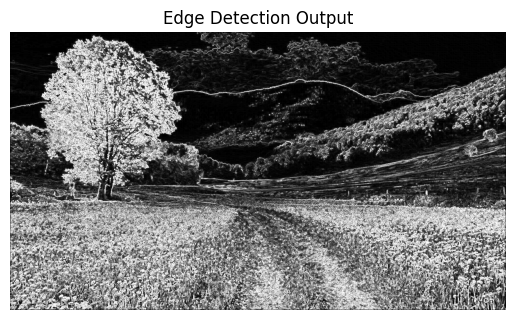

In [36]:
import cv2
from matplotlib import pyplot as plt

# Read and display the output image
output_image_path = '/content/output_sobel.jpeg'
output_image = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)  # Use IMREAD_GRAYSCALE if it's a single-channel image

# Display the image
plt.imshow(output_image, cmap='gray')
plt.title('Edge Detection Output')
plt.axis('off')  # Hide the axes
plt.show()
